* Parte 1
- Verificación visual

In [107]:
pts = [(0, 1), (1, 5), (2, 3)]

In [108]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [109]:
import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

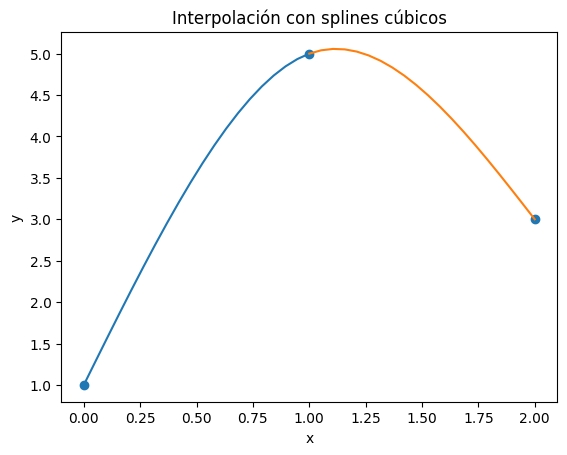

In [110]:
s = [
    {"a": 1, "b": 11/2, "c": 0, "d": -3/2},
    {"a": 5, "b": 1, "c": -9/2, "d": 3/2},
]


dibujar_spline(pts, s)

In [111]:
pts2 = [(0, -5), (1, -4), (2, 3)]

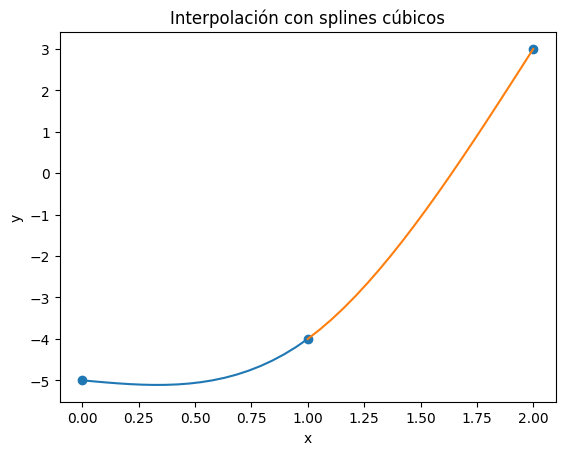

In [112]:
s2 = [
    {"a": -5, "b": -1/2, "c": 0, "d": 3/2},
    {"a": -4, "b": 4, "c": 9/2, "d": -3/2},
]


dibujar_spline(pts2, s2)

In [113]:
pts3 = [(0, -1), (1, 1), (2, 5), (3, 2)]

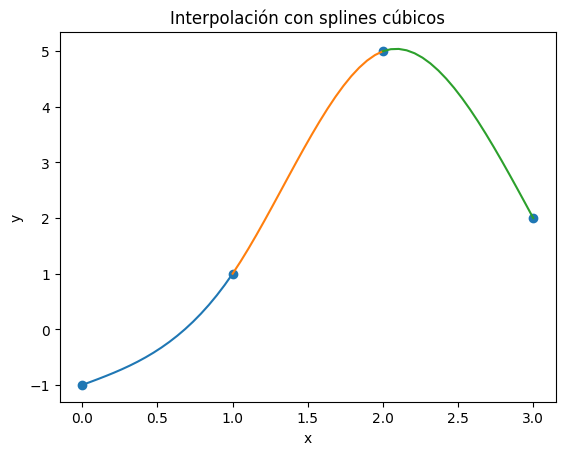

In [114]:
s3 = [
    {"a": -1, "b": 1, "c": 0, "d": 1},
    {"a": 1, "b": 4, "c": 3, "d": -3},
    {"a": 5, "b": 1, "c": -6, "d": 2},
]


dibujar_spline(pts3, s3)

* Parte 2
- Completar en base al pseudocódigo

- Poner el if si pasa de un rango o no


In [115]:
import sympy as sym
from IPython.display import display


# ###################################################################
# Devuelve: lista de expresiones simbólicas para cada spline cúbico para S0, S1, ..., Sn-1
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    """
    - zip(xs, ys) empareja los elementos de ambas listas por posición,
    creando una lista de tuplas (x, y). 

    - sorted(zip(xs, ys)) ordena esta lista de tuplas usando el primer elemento 
    de cada tupla (x) como clave de ordenación gracias a la función lambda, 
    que es el segundo argumento de sorted.

    - lambda x: x[0] es una función anónima que toma de cada tupla su posicón 0
    (el valor de x) para usarlo como criterio de ordenación.
    """
    points = sorted(zip(xs, ys), key=lambda x: x[0]) # Sort points by x

    # Garantizar x0 < x1 < ... < xn, sin romper correspondencia con ys
    xs = [x for x, _ in points] # Extraer xs ordenados
    ys = [y for _, y in points] # Extraer ys correspondientes a los xs ordenados

    # len(points) : Ejemplo: Si points = [(0, 1), (1, 5), (2, 3)], entonces len(points) = 3.
    n = len(points) - 1  # number of splines: ptos -1

    # el spline depende completamente de qué tan separados están los puntos, por ello se calcula la distancia entre cada par de puntos consecutivos y se guarda en el vector h
    # del ejemplo anterior si xs = [0, 1, 2], entonces h = [1, 1] porque 1 - 0 = 1 y 2 - 1 = 1.
    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between  contiguous xs

    # Inicializar el vector alpha
    alpha = [0] * (n + 1)
    for i in range(1, n):
        # Estamos midiendo cómo deben ajustarse las curvaturas para mantener continuidad suave entre los splines. La fórmula se deriva de las condiciones de continuidad de la primera y segunda derivada en los puntos de unión.
        """
        Para que haya continuidad en la función: S_i(X_i+1) = S_i+1(X_i+1) <-- Sin saltos
        Para que haya continuidad en la primera derivada: S_i'(X_i+1) = S_i+1'(X_i+1) <-- Sin cambios bruscos en la pendiente: No debe haber esquinas o ángulos agudos en la curva.
        Para que haya continuidad en la segunda derivada: S_i''(X_i+1) = S_i+1''(X_i+1) <-- Sin cambios bruscos en la curvatura: La curva debe ser suave, sin cambios abruptos en la curvatura.
        """
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])
                # Perndiente del intervalo derecho - pendiente del intervalo izquierdo, ajustada por la distancia entre los puntos.
                # Si los puntos están muy separados, el ajuste de curvatura será mayor para mantener la suavidad.
                # Si los puntos están muy cercanos, el ajuste de curvatura será menor, lo que refleja que no se necesita tanta curvatura para mantener la suavidad.
    
    # Algoritmo de thomas : versión optimizada de eliminación Gaussiana para matrices tridiagonales, que se divide en:
    # Forward elimination: Se transforma la matriz tridiagonal en una matriz triangular superior.

    l = [1]
    u = [0]
    z = [0]
    
    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]] 

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    # Back substitution: Se resuelve el sistema triangular superior para encontrar los coeficientes c.
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1] # controla la curvatura en el intervalo j.
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3 # pendiente inicial del spline en el intervalo.
        d = (c[j + 1] - c[j]) / (3 * h[j]) # como cambia la curvatura a lo largo del intervalo.
        a  = ys[j]
        print(j, a, b, c[j], d)
        S  = a + b * (x - xs[j]) + c[j] * (x - xs[j])**2 + d * (x - xs[j])**3

        splines.append(S)
    # Dado que los splines quedaron al revez porque se recorrió el vector de atrás hacia adelante, se invierte la lista para que S0, S1, ..., Sn-1 estén en orden.
    splines.reverse()
    return splines # la lista completa de polinomios spline simbólicos.

In [116]:
xs = [0, 1, 2]
ys = [-5, -4, 3]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]   
print("______")
_ = [display(s.expand()) for s in splines]

1 -4 4.0 4.5 -1.5
0 -5 -0.5 0.0 1.5


1.5*x**3 - 0.5*x - 5

4.0*x - 1.5*(x - 1)**3 + 4.5*(x - 1)**2 - 8.0

______


1.5*x**3 - 0.5*x - 5

-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym


def graficar_splines(splines, xs, num_puntos=100):
    """
    Grafica una lista de splines cúbicos por intervalos.

    Parámetros:
    - splines: lista de expresiones simbólicas SymPy
    - xs: lista de puntos x originales
    - num_puntos: cantidad de puntos por intervalo
    """

    # Variable simbólica
    x = sym.Symbol("x")

    plt.figure(figsize=(8, 5))

    # ==========================================================
    # Recorremos cada spline y su intervalo correspondiente
    # ==========================================================
    for i, spline in enumerate(splines):

        # Intervalo del spline actual
        x_inicio = xs[i]
        x_fin = xs[i + 1]

        # Crear puntos del intervalo
        x_vals = np.linspace(x_inicio, x_fin, num_puntos)

        y_vals = []

        # ======================================================
        # Evaluar el spline SOLO en su intervalo
        # ======================================================
        for valor in x_vals:

            # IF para verificar que pertenece al intervalo
            if x_inicio <= valor <= x_fin:

                # Evaluación usando .subs()
                y = spline.subs(x, valor)

                # Convertir a float para matplotlib
                y_vals.append(float(y))

        # Graficar spline actual
        plt.plot(x_vals, y_vals, label=f"Spline {i}")

    # ==========================================================
    # Graficar puntos originales
    # ==========================================================
    plt.scatter(xs, ys, color="red", zorder=3, label="Puntos")

    # Decoración
    plt.title("Interpolación por Splines Cúbicos")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()

    plt.show()

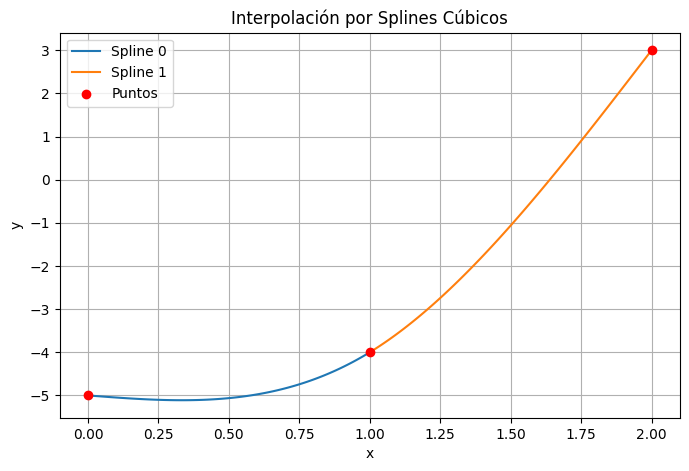

In [118]:
graficar_splines(splines, xs)

In [119]:
splines[1]

4.0*x - 1.5*(x - 1)**3 + 4.5*(x - 1)**2 - 8.0

Parte 3
- Mover x_n y generar automaticamente el splin

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sym
from IPython.display import HTML


def animar_splines(splines, xs, ys, num_puntos=200):
    """
    Anima la construcción progresiva de splines cúbicos.

    Parámetros:
    - splines: lista de splines simbólicos
    - xs: puntos x originales
    - ys: puntos y originales
    - num_puntos: resolución de cada spline
    """

    x = sym.Symbol("x")

    # ==========================================================
    # Crear figura
    # ==========================================================
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.set_title("Animación de Splines Cúbicos")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)

    # Límites automáticos
    ax.set_xlim(min(xs) - 1, max(xs) + 1)
    ax.set_ylim(min(ys) - 2, max(ys) + 2)

    # Línea animada
    linea, = ax.plot([], [], lw=2)

    # Puntos originales
    puntos_pasados, = ax.plot([], [], 'ro')

    # Punto móvil
    punto_actual, = ax.plot([], [], 'bo')

    # ==========================================================
    # Construcción de datos completos
    # ==========================================================
    x_total = []
    y_total = []

    for i, spline in enumerate(splines):

        x_inicio = xs[i]
        x_fin = xs[i + 1]

        x_vals = np.linspace(x_inicio, x_fin, num_puntos)

        for valor in x_vals:

            # Verificar intervalo correcto
            if x_inicio <= valor <= x_fin:

                # Evaluar usando .subs()
                y = spline.subs(x, valor)

                x_total.append(valor)
                y_total.append(float(y))

    # ==========================================================
    # Inicialización
    # ==========================================================
    def init():

        linea.set_data([], [])
        puntos_pasados.set_data([], [])
        punto_actual.set_data([], [])

        return linea, puntos_pasados, punto_actual

    # ==========================================================
    # Actualización por frame
    # ==========================================================
    def update(frame):

        # Dibujar curva progresivamente
        linea.set_data(x_total[:frame], y_total[:frame])

        # Punto actual moviéndose
        punto_actual.set_data(
            [x_total[frame]],
            [y_total[frame]]
        )

        # ==========================================
        # Mostrar puntos originales recorridos
        # ==========================================
        puntos_x = []
        puntos_y = []

        x_actual = x_total[frame]

        for x_original, y_original in zip(xs, ys):

            if x_actual >= x_original:

                puntos_x.append(x_original)
                puntos_y.append(y_original)

        puntos_pasados.set_data(puntos_x, puntos_y)

        return linea, puntos_pasados, punto_actual

    # ==========================================================
    # Crear animación
    # ==========================================================
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(x_total),
        init_func=init,
        interval=20,
        blit=True,
        repeat=False
    )

    # Evita mostrar figura vacía
    plt.close()

    # Retornar animación HTML
    return HTML(ani.to_jshtml())

In [121]:
animar_splines(splines, xs, ys)